In [17]:
import pandas as pd
import nltk
import re

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [18]:
df = pd.read_csv("/content/Hotel_Reviews.csv")

In [19]:
print(df.columns)

Index(['Hotel_Address', 'Additional_Number_of_Scoring', 'Review_Date',
       'Average_Score', 'Hotel_Name', 'Reviewer_Nationality',
       'Negative_Review', 'Review_Total_Negative_Word_Counts',
       'Total_Number_of_Reviews', 'Positive_Review',
       'Review_Total_Positive_Word_Counts',
       'Total_Number_of_Reviews_Reviewer_Has_Given', 'Reviewer_Score', 'Tags',
       'days_since_review', 'lat', 'lng'],
      dtype='object')


In [20]:
# Replace missing values with empty strings
df["Positive_Review"] = df["Positive_Review"].fillna("")
df["Negative_Review"] = df["Negative_Review"].fillna("")

# Combine positive and negative reviews
df["Review"] = df["Positive_Review"] + " " + df["Negative_Review"]

print(df[["Review"]].head())

                                              Review
0   Only the park outside of the hotel was beauti...
1   No real complaints the hotel was great great ...
2   Location was good and staff were ok It is cut...
3   Great location in nice surroundings the bar a...
4   Amazing location and building Romantic settin...


In [22]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    words = text.split()   # No NLTK tokenizer needed

    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

In [23]:
df["Clean_Review"] = df["Review"].apply(preprocess)

In [24]:
from textblob import TextBlob

def sentiment(review):
    score = TextBlob(review).sentiment.polarity

    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

df["Sentiment"] = df["Clean_Review"].apply(sentiment)

In [25]:
issues = {
    "Room": ["room", "bed", "bathroom", "clean"],
    "Staff": ["staff", "manager", "reception", "service"],
    "Food": ["food", "breakfast", "dinner", "restaurant"],
    "Amenities": ["wifi", "pool", "gym", "parking", "spa"]
}

def identify_issue(review):
    found = []
    review = review.lower()

    for category, keywords in issues.items():
        if any(word in review for word in keywords):
            found.append(category)

    return ", ".join(found) if found else "Other"

df["Issue_Category"] = df["Review"].apply(identify_issue)

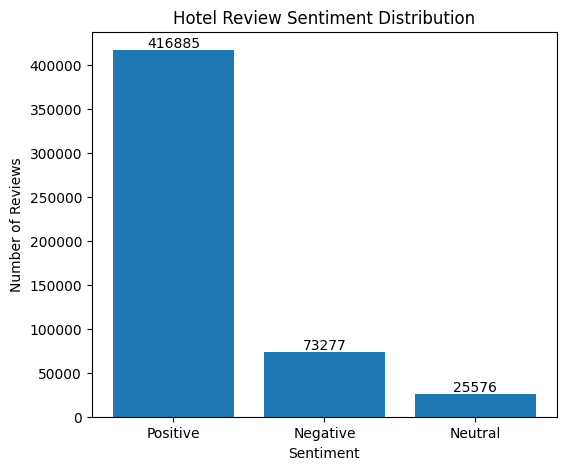

In [26]:
import matplotlib.pyplot as plt

# Count sentiments
sentiment_counts = df["Sentiment"].value_counts()

# Plot bar chart
plt.figure(figsize=(6,5))
plt.bar(sentiment_counts.index, sentiment_counts.values)

plt.title("Hotel Review Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

# Display values on bars
for i, value in enumerate(sentiment_counts.values):
    plt.text(i, value, str(value), ha='center', va='bottom')

plt.show()

In [27]:
print(df[["Review", "Sentiment", "Issue_Category"]].head())

                                              Review Sentiment  \
0   Only the park outside of the hotel was beauti...  Positive   
1   No real complaints the hotel was great great ...  Positive   
2   Location was good and staff were ok It is cut...  Positive   
3   Great location in nice surroundings the bar a...  Positive   
4   Amazing location and building Romantic settin...  Positive   

      Issue_Category  
0               Room  
1  Room, Staff, Food  
2  Room, Staff, Food  
3  Room, Staff, Food  
4        Room, Staff  


In [28]:
from collections import Counter

# Total reviews
total_reviews = len(df)

# Sentiment counts
sentiment_counts = df["Sentiment"].value_counts()

positive = sentiment_counts.get("Positive", 0)
neutral = sentiment_counts.get("Neutral", 0)
negative = sentiment_counts.get("Negative", 0)

# Percentages
positive_pct = (positive / total_reviews) * 100
neutral_pct = (neutral / total_reviews) * 100
negative_pct = (negative / total_reviews) * 100

# Count issue categories
issues = []
for item in df["Issue_Category"]:
    issues.extend(item.split(", "))

issue_counts = Counter(issues)

# Print Report
print("=" * 50)
print("      HOTEL CUSTOMER SATISFACTION REPORT")
print("=" * 50)

print(f"Total Reviews Analyzed : {total_reviews}")

print("\nSentiment Analysis")
print("-" * 50)
print(f"Positive Reviews : {positive} ({positive_pct:.2f}%)")
print(f"Neutral Reviews  : {neutral} ({neutral_pct:.2f}%)")
print(f"Negative Reviews : {negative} ({negative_pct:.2f}%)")

print("\nMost Mentioned Service Categories")
print("-" * 50)

for category, count in issue_counts.most_common():
    print(f"{category:<15} : {count}")

print("\nOverall Customer Satisfaction")
print("-" * 50)

if positive_pct >= 70:
    print("Excellent - Customers are highly satisfied.")
elif positive_pct >= 50:
    print("Good - Most customers are satisfied, but improvements are needed.")
else:
    print("Needs Improvement - Customer satisfaction is below expectations.")

print("=" * 50)

      HOTEL CUSTOMER SATISFACTION REPORT
Total Reviews Analyzed : 515738

Sentiment Analysis
--------------------------------------------------
Positive Reviews : 416885 (80.83%)
Neutral Reviews  : 25576 (4.96%)
Negative Reviews : 73277 (14.21%)

Most Mentioned Service Categories
--------------------------------------------------
Room            : 325502
Staff           : 255193
Food            : 166229
Amenities       : 75961
Other           : 73197

Overall Customer Satisfaction
--------------------------------------------------
Excellent - Customers are highly satisfied.
